In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from database import get_engine
import warnings
warnings.filterwarnings('ignore')

engine = get_engine()

# Load factors
factors_df = pd.read_sql("SELECT * FROM factors ORDER BY ticker, date", engine)
factors_df['date'] = pd.to_datetime(factors_df['date'])

print("Data loaded successfully!")
print(f"Factors: {len(factors_df):,} rows")

Data loaded successfully!
Factors: 37,725 rows


In [2]:
# Rebuild Backtest 
def get_monthly_rebalance_dates(df):
    df['year_month'] = df['date'].dt.to_period('M')
    monthly_dates = (
        df.groupby('year_month')['date']
        .max()
        .reset_index()
    )
    monthly_dates.columns = ['year_month', 'rebalance_date']
    return monthly_dates

FACTOR_WEIGHTS = {
    'mom_12m':        0.25,
    'mom_6m':         0.15,
    'vol_21d':       -0.20,
    'volume_ratio':   0.10,
    'dist_from_high':-0.15,
    'rsi':           -0.15
}

def normalize_factor(series):
    return (series - series.mean()) / series.std()

def rank_stocks_at_date(factors_df, rebalance_date):
    snapshot = factors_df[factors_df['date'] == rebalance_date].copy()
    if len(snapshot) < 5:
        return None
    for factor, weight in FACTOR_WEIGHTS.items():
        z_col = f'z_{factor}'
        snapshot[z_col] = normalize_factor(snapshot[factor]) * weight
    z_cols = [f'z_{f}' for f in FACTOR_WEIGHTS.keys()]
    snapshot['combined_score'] = snapshot[z_cols].sum(axis=1)
    snapshot['rank'] = snapshot['combined_score'].rank(ascending=False)
    return snapshot[['date', 'ticker', 'combined_score', 'rank']].sort_values('rank')

def run_backtest(factors_df, rebalance_dates):
    results = []
    for i in range(len(rebalance_dates) - 1):
        current_date = rebalance_dates['rebalance_date'].iloc[i]
        next_date    = rebalance_dates['rebalance_date'].iloc[i + 1]
        rankings     = rank_stocks_at_date(factors_df, current_date)
        if rankings is None:
            continue
        top_stocks    = rankings[rankings['rank'] <= 5]['ticker'].tolist()
        bottom_stocks = rankings[rankings['rank'] > 10]['ticker'].tolist()
        current_prices = factors_df[factors_df['date'] == current_date].set_index('ticker')['close']
        next_prices    = factors_df[factors_df['date'] == next_date].set_index('ticker')['close']
        top_returns    = []
        bottom_returns = []
        for ticker in top_stocks:
            if ticker in current_prices.index and ticker in next_prices.index:
                ret = (next_prices[ticker] - current_prices[ticker]) / current_prices[ticker]
                top_returns.append(ret)
        for ticker in bottom_stocks:
            if ticker in current_prices.index and ticker in next_prices.index:
                ret = (next_prices[ticker] - current_prices[ticker]) / current_prices[ticker]
                bottom_returns.append(ret)
        spy_current = factors_df[(factors_df['date'] == current_date) & (factors_df['ticker'] == 'SPY')]['close'].values
        spy_next    = factors_df[(factors_df['date'] == next_date)    & (factors_df['ticker'] == 'SPY')]['close'].values
        if len(spy_current) > 0 and len(spy_next) > 0:
            spy_return = (spy_next[0] - spy_current[0]) / spy_current[0]
        else:
            spy_return = np.nan
        results.append({
            'date':          current_date,
            'next_date':     next_date,
            'top_return':    np.mean(top_returns) if top_returns else np.nan,
            'bottom_return': np.mean(bottom_returns) if bottom_returns else np.nan,
            'spy_return':    spy_return,
            'top_stocks':    top_stocks,
            'bottom_stocks': bottom_stocks
        })
    return pd.DataFrame(results)

rebalance_dates = get_monthly_rebalance_dates(factors_df)
backtest_results = run_backtest(factors_df, rebalance_dates)

backtest_results['cumulative_top']    = (1 + backtest_results['top_return']).cumprod()
backtest_results['cumulative_bottom'] = (1 + backtest_results['bottom_return']).cumprod()
backtest_results['cumulative_spy']    = (1 + backtest_results['spy_return']).cumprod()

print(f"Backtest complete — {len(backtest_results)} monthly periods")
print(f"Long Portfolio:  {backtest_results['cumulative_top'].iloc[-1]:.2f}x")
print(f"Short Portfolio: {backtest_results['cumulative_bottom'].iloc[-1]:.2f}x")
print(f"SPY Benchmark:   {backtest_results['cumulative_spy'].iloc[-1]:.2f}x")

Backtest complete — 119 monthly periods
Long Portfolio:  14.99x
Short Portfolio: 5.42x
SPY Benchmark:   3.51x


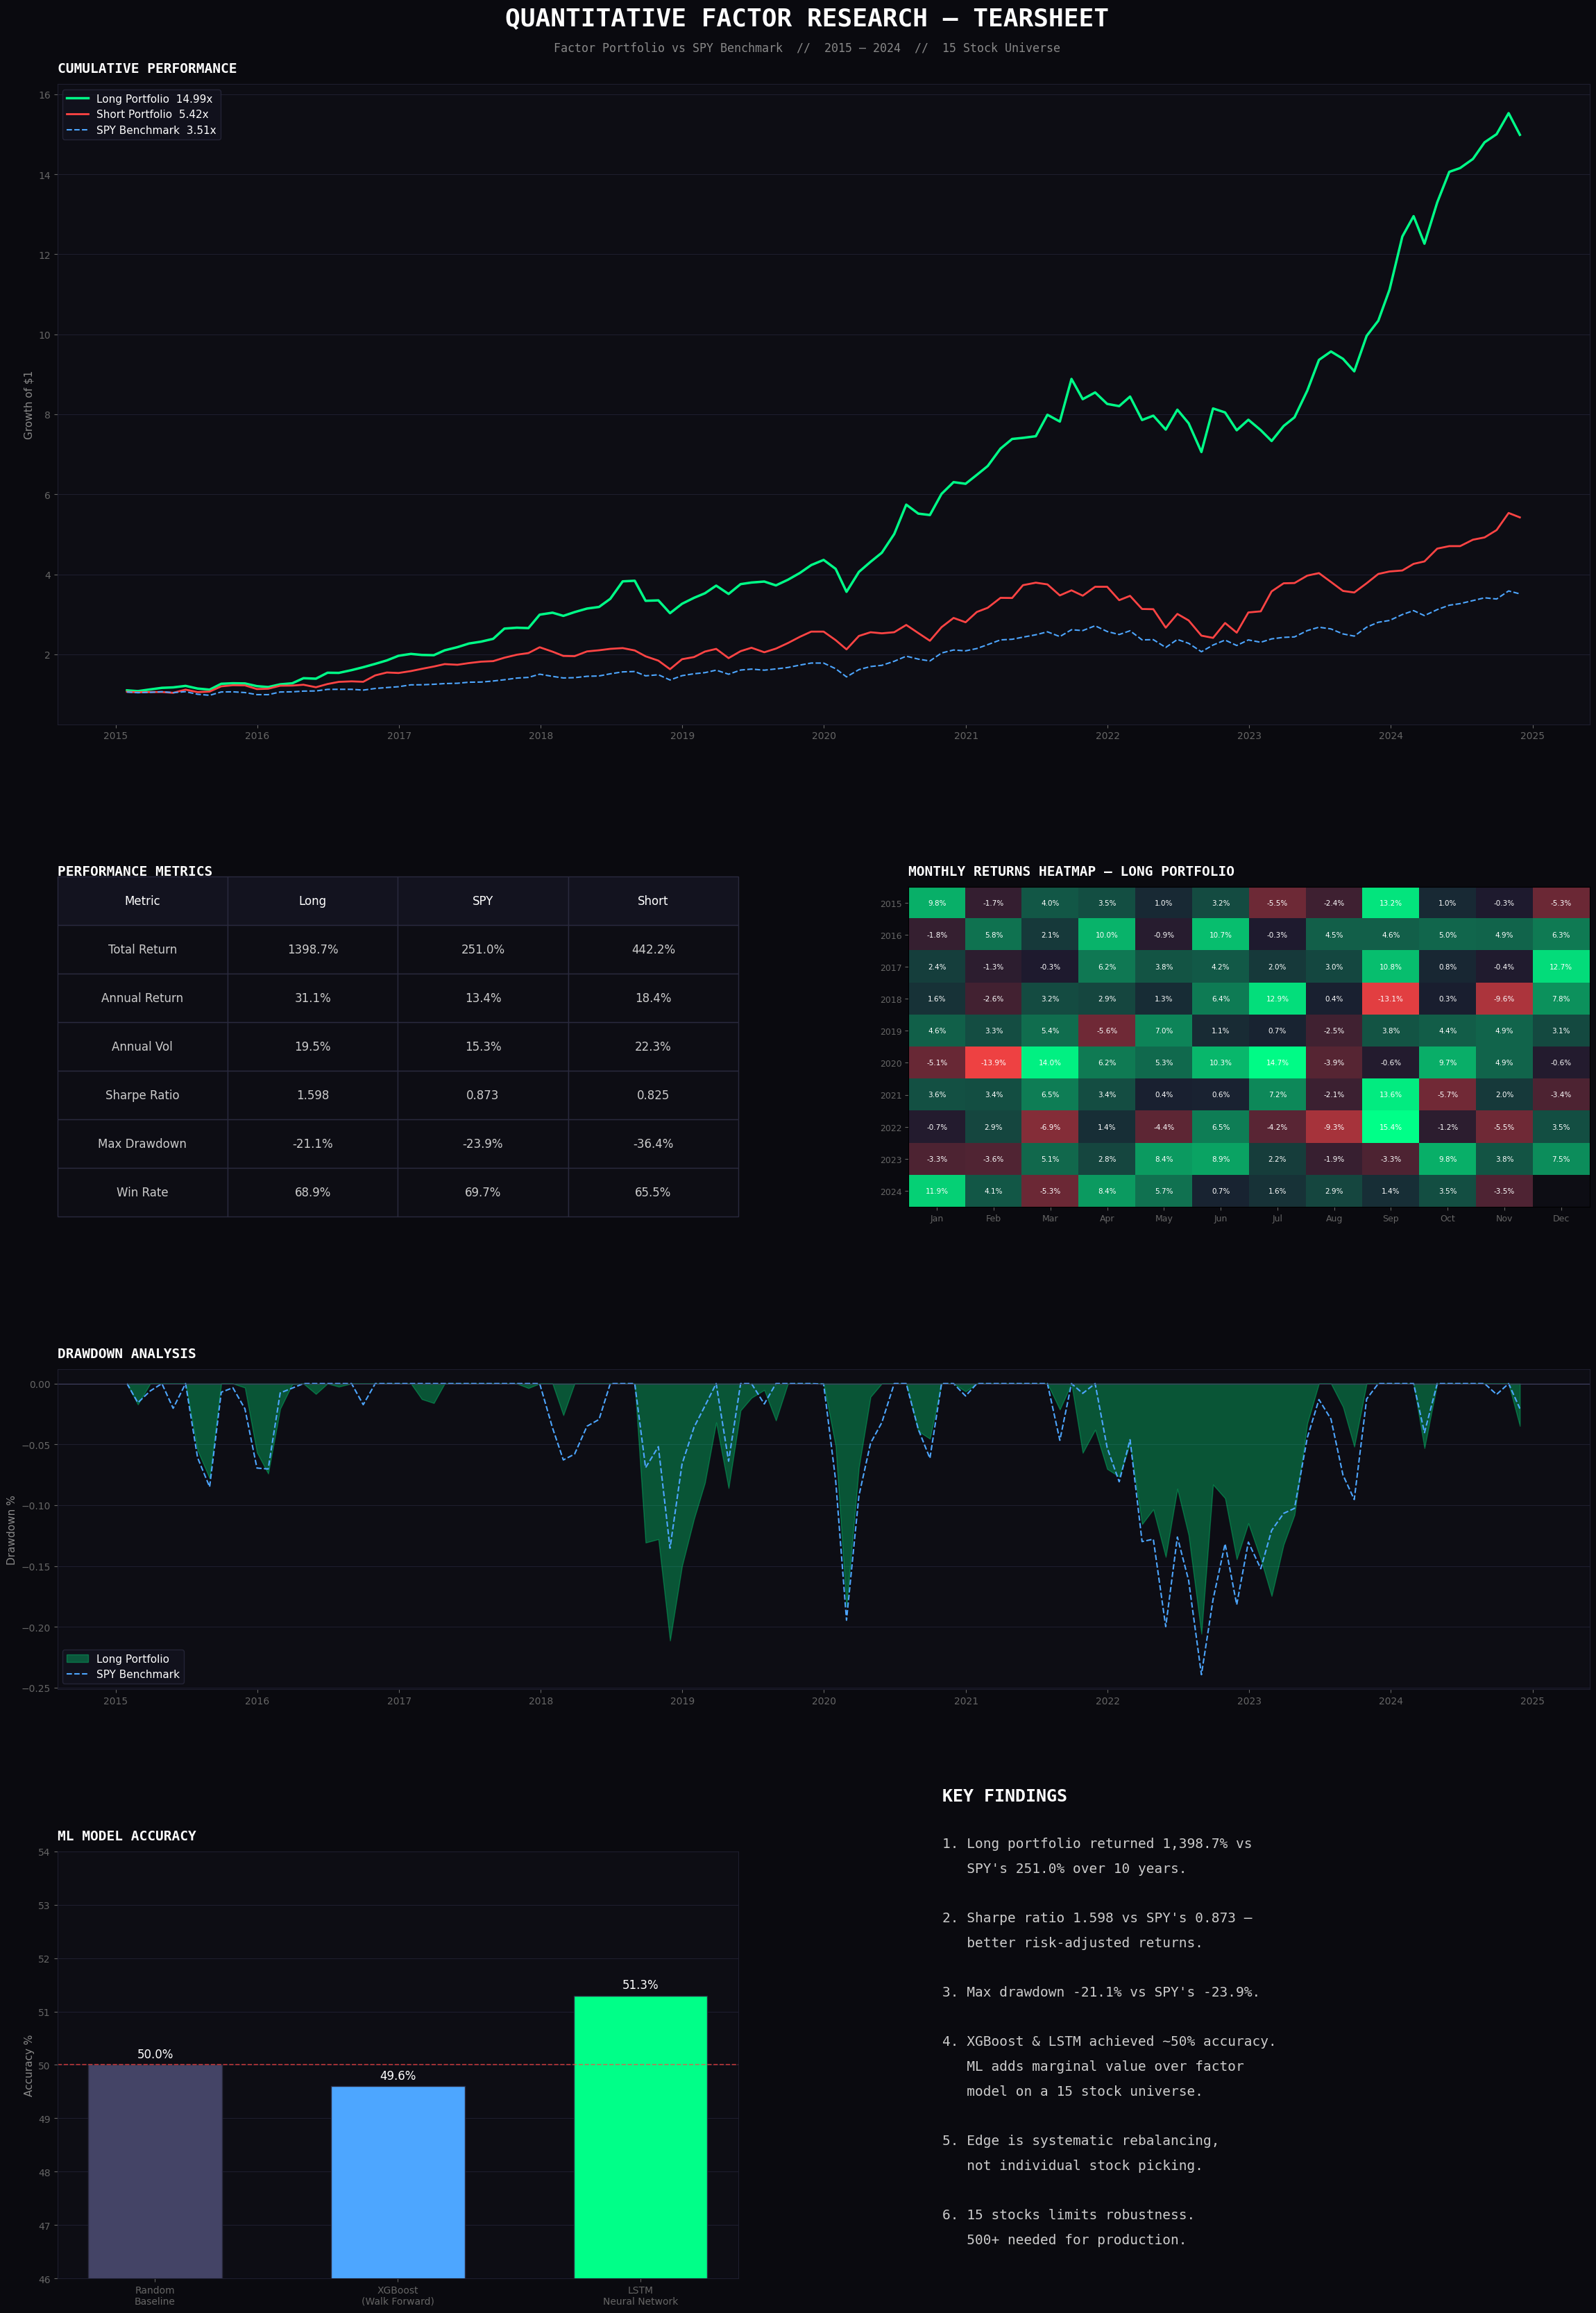

In [45]:
fig = plt.figure(figsize=(24, 34), facecolor='#0a0a0f')
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.38, wspace=0.25,
                        height_ratios=[3, 1.5, 1.5, 2],
                        top=0.95, bottom=0.02, left=0.05, right=0.97)

# ── Header
fig.text(0.5, 0.975, 'QUANTITATIVE FACTOR RESEARCH — TEARSHEET',
         ha='center', fontsize=26, fontweight='bold',
         color='white', fontfamily='monospace')
fig.text(0.5, 0.964, 'Factor Portfolio vs SPY Benchmark  //  2015 — 2024  //  15 Stock Universe',
         ha='center', fontsize=12, color='#888888', fontfamily='monospace')

# ── Panel 1: Cumulative Performance
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#0d0d14')
ax1.plot(backtest_results['date'], backtest_results['cumulative_top'],
         color='#00ff88', linewidth=2.5,
         label=f"Long Portfolio  {backtest_results['cumulative_top'].iloc[-1]:.2f}x")
ax1.plot(backtest_results['date'], backtest_results['cumulative_bottom'],
         color='#ff4444', linewidth=2,
         label=f"Short Portfolio  {backtest_results['cumulative_bottom'].iloc[-1]:.2f}x")
ax1.plot(backtest_results['date'], backtest_results['cumulative_spy'],
         color='#4da6ff', linewidth=1.5, linestyle='--',
         label=f"SPY Benchmark  {backtest_results['cumulative_spy'].iloc[-1]:.2f}x")
ax1.set_title('CUMULATIVE PERFORMANCE', color='white', fontsize=14,
              fontweight='bold', fontfamily='monospace', loc='left', pad=12)
ax1.set_ylabel('Growth of $1', color='#888888', fontsize=11)
ax1.tick_params(colors='#666666', labelsize=10)
ax1.spines[['top','right','left','bottom']].set_color('#1e1e2e')
ax1.yaxis.grid(True, color='#1e1e2e', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.legend(fontsize=11, facecolor='#13131f', edgecolor='#2a2a3e', labelcolor='white')

# ── Panel 2: Metrics Table
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#0d0d14')
ax2.axis('off')

def get_metrics(returns):
    total  = (1 + returns).cumprod().iloc[-1] - 1
    ann    = (1 + total) ** (1/10) - 1
    vol    = returns.std() * np.sqrt(12)
    sharpe = ann / vol
    cum    = (1 + returns).cumprod()
    dd     = ((cum - cum.cummax()) / cum.cummax()).min()
    wr     = (returns > 0).mean()
    return [f"{total*100:.1f}%", f"{ann*100:.1f}%", f"{vol*100:.1f}%",
            f"{sharpe:.3f}", f"{dd*100:.1f}%", f"{wr*100:.1f}%"]

metrics_labels = ['Total Return', 'Annual Return', 'Annual Vol',
                  'Sharpe Ratio', 'Max Drawdown', 'Win Rate']
long_metrics  = get_metrics(backtest_results['top_return'])
short_metrics = get_metrics(backtest_results['bottom_return'])
spy_metrics   = get_metrics(backtest_results['spy_return'])

table_data = [[m, l, s, b] for m, l, s, b in
              zip(metrics_labels, long_metrics, spy_metrics, short_metrics)]
table = ax2.table(
    cellText=table_data,
    colLabels=['Metric', 'Long', 'SPY', 'Short'],
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 4.2)
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#13131f' if row == 0 else '#0d0d14')
    cell.set_text_props(color='white' if row == 0 else '#cccccc')
    cell.set_edgecolor('#2a2a3e')
ax2.set_title('PERFORMANCE METRICS', color='white', fontsize=14,
              fontweight='bold', fontfamily='monospace', loc='left', pad=12)

# ── Panel 3: Monthly Heatmap
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#0d0d14')
monthly = backtest_results.copy()
monthly['year']  = monthly['date'].dt.year
monthly['month'] = monthly['date'].dt.month
pivot = monthly.pivot_table(values='top_return', index='year',
                             columns='month', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
cmap = LinearSegmentedColormap.from_list('rg', ['#ff4444','#1a1a2e','#00ff88'])
ax3.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=-0.15, vmax=0.15)
ax3.set_xticks(range(12))
ax3.set_xticklabels(pivot.columns, fontsize=9, color='#888888')
ax3.set_yticks(range(len(pivot.index)))
ax3.set_yticklabels(pivot.index, fontsize=9, color='#888888')
ax3.tick_params(colors='#666666')
for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax3.text(j, i, f'{val*100:.1f}%', ha='center', va='center',
                    fontsize=7.5, color='white')
ax3.set_title('MONTHLY RETURNS HEATMAP — LONG PORTFOLIO',
              color='white', fontsize=14, fontweight='bold',
              fontfamily='monospace', loc='left', pad=12)

# ── Panel 4: Drawdown
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor('#0d0d14')
cum_top = (1 + backtest_results['top_return']).cumprod()
cum_spy = (1 + backtest_results['spy_return']).cumprod()
dd_top  = (cum_top - cum_top.cummax()) / cum_top.cummax()
dd_spy  = (cum_spy - cum_spy.cummax()) / cum_spy.cummax()
ax4.fill_between(backtest_results['date'], dd_top, 0, alpha=0.3,
                 color='#00ff88', label='Long Portfolio')
ax4.plot(backtest_results['date'], dd_spy, color='#4da6ff',
         linewidth=1.5, linestyle='--', label='SPY Benchmark')
ax4.axhline(y=0, color='#444466', linewidth=0.8)
ax4.set_title('DRAWDOWN ANALYSIS', color='white', fontsize=14,
              fontweight='bold', fontfamily='monospace', loc='left', pad=12)
ax4.set_ylabel('Drawdown %', color='#888888', fontsize=11)
ax4.tick_params(colors='#666666', labelsize=10)
ax4.spines[['top','right','left','bottom']].set_color('#1e1e2e')
ax4.yaxis.grid(True, color='#1e1e2e', linewidth=0.8)
ax4.legend(fontsize=11, facecolor='#13131f', edgecolor='#2a2a3e', labelcolor='white')
ax4.set_axisbelow(True)

# ── Panel 5: ML Accuracy
ax5 = fig.add_subplot(gs[3, 0])
ax5.set_facecolor('#0d0d14')
ml_models = ['Random\nBaseline', 'XGBoost\n(Walk Forward)', 'LSTM\nNeural Network']
ml_accs   = [50.0, 49.6, 51.3]
ml_colors = ['#444466', '#4da6ff', '#00ff88']
bars = ax5.bar(ml_models, ml_accs, color=ml_colors, width=0.55, edgecolor='#2a2a3e')
ax5.axhline(y=50, color='#ff4444', linewidth=1.2, linestyle='--', alpha=0.7)
ax5.set_ylim(46, 54)
ax5.set_ylabel('Accuracy %', color='#888888', fontsize=11)
ax5.tick_params(colors='#666666', labelsize=10)
ax5.spines[['top','right','left','bottom']].set_color('#1e1e2e')
ax5.yaxis.grid(True, color='#1e1e2e', linewidth=0.8)
ax5.set_axisbelow(True)
ax5.set_title('ML MODEL ACCURACY', color='white', fontsize=14,
              fontweight='bold', fontfamily='monospace', loc='left', pad=12)
for bar, acc in zip(bars, ml_accs):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
             f'{acc}%', ha='center', va='bottom', color='white', fontsize=12)

# ── Panel 6: Key Findings
ax6 = fig.add_subplot(gs[3, 1])
ax6.set_facecolor('#0d0d14')
ax6.axis('off')

findings = [
    "KEY FINDINGS",
    "",
    "1. Long portfolio returned 1,398.7% vs",
    "   SPY's 251.0% over 10 years.",
    "",
    "2. Sharpe ratio 1.598 vs SPY's 0.873 —",
    "   better risk-adjusted returns.",
    "",
    "3. Max drawdown -21.1% vs SPY's -23.9%.",
    "",
    "4. XGBoost & LSTM achieved ~50% accuracy.",
    "   ML adds marginal value over factor",
    "   model on a 15 stock universe.",
    "",
    "5. Edge is systematic rebalancing,",
    "   not individual stock picking.",
    "",
    "6. 15 stocks limits robustness.",
    "   500+ needed for production.",
]

for i, line in enumerate(findings):
    color  = 'white' if i == 0 else '#cccccc'
    size   = 18 if i == 0 else 14
    weight = 'bold' if i == 0 else 'normal'
    ax6.text(0.05, 1.15 - i*0.058, line, transform=ax6.transAxes,
             fontsize=size, color=color, fontweight=weight,
             fontfamily='monospace', va='top')

plt.savefig('../data/tearsheet.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
